# Optimal Interpolation / BLUE on Lorenz-63

The closed-form linear-Gaussian baseline. Given prior $\mathcal{N}(x_b, B)$
and obs $y \mid x \sim \mathcal{N}(Hx, R)$, the posterior mean is

$$
x^* = x_b + K (y - H x_b), \qquad K = B H^\top (H B H^\top + R)^{-1}.
$$

No iteration, no convergence criterion. We expect this to set the
**floor** of the benchmark: with a diagonal $B$ and observations on
only the $x$-component, the analysis can only update the observed
entries and leaves $y, z$ at the prior.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import generate_problem, run_method

## 1. Load the shared problem

Every benchmark notebook starts with this exact call so the numbers
stack into one comparison table.

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)
print(f"truth shape: {prob.truth.shape}")
print(f"obs density: {int(prob.mask.sum())} / {prob.mask.size} entries observed")

truth shape: (41, 3)
obs density: 11 / 123 entries observed


## 2. Build the OI model

`LinearObs` with identity $H$ over the full $(T+1, 3)$ state — every
entry is "observed in principle" but the mask zeros out the
unobserved entries.

In [3]:
H = lx.IdentityLinearOperator(jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32))
oi = vdx.OptimalInterpolation(
    obs_op=vdx.LinearObs(H_mat=H),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
)

## 3. Run + time

In [4]:
result = run_method("oi", lambda: oi(batch)[0], prob)
print(f"OI RMSE (total):       {result.rmse_total:.3f}")
print(f"OI RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"OI runtime:            {result.runtime_ms:.1f} ms")

OI RMSE (total):       16.866
OI RMSE per component: x=7.269  y=8.494  z=26.990
OI runtime:            413.8 ms


## 4. Visualise

Three rows for the three Lorenz components. Truth, observations (only
on $x$), and the OI analysis.

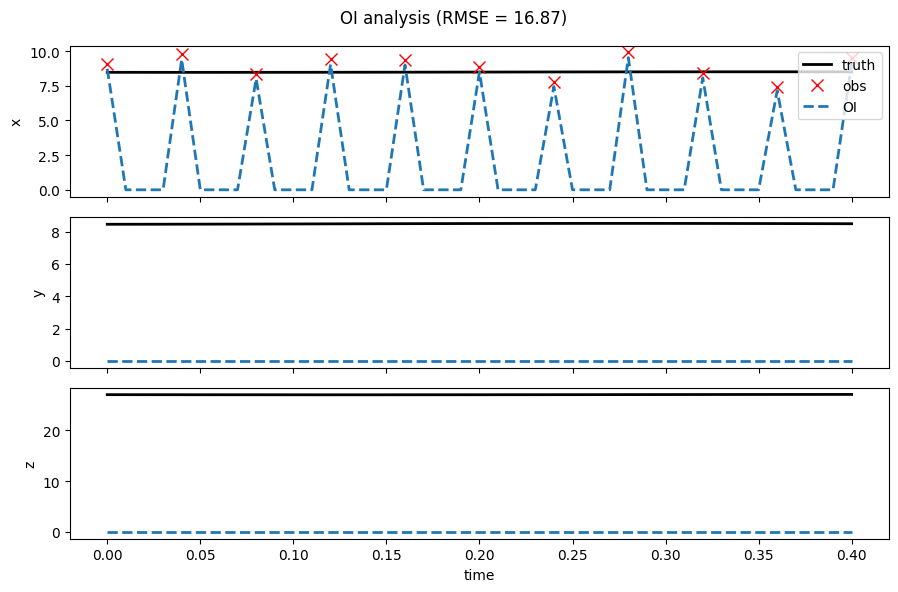

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
labels = ["x", "y", "z"]
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_t) > 0:
        ax.plot(obs_t, obs_v, "rx", ms=8, label="obs")
    ax.plot(t, result.mean[:, i], "C0--", lw=2, label="OI")
    ax.set_ylabel(labels[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"OI analysis (RMSE = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 5. Discussion

As expected: the OI analysis tracks $x$ well at the observed
timesteps and **collapses to the prior** (zero) on $y, z$. With
diagonal $B$ there is no cross-component coupling, so no information
flows from $x$-observations to the other components.

The next notebook — [3DVar](02_threedvar.ipynb) — solves the same
cost function iteratively and recovers the *same* answer in this
linear-Gaussian limit (per Decision D14 in the vardax design).
Things start getting interesting at notebook
[03_strong_4dvar](03_strong_4dvar.ipynb), where the dynamics
constraint finally lets the unobserved components emerge.